In [ ]:
# ============================================================
# INSTALL
# ============================================================

!pip install -q transformers datasets evaluate sentencepiece sacrebleu bert-score accelerate rouge_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import evaluate
import shutil
import gc
import os

from sklearn.model_selection import train_test_split
from datasets import Dataset
from bert_score import score as bertscore

from transformers import (
    MBart50TokenizerFast,
    MBartForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback
)

In [ ]:
# ============================================================
# MOUNT DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/mBART_sunday_fine"

folders = [
    "dataset",
    "checkpoints",
    "final_model",
    "tokenizer",
    "logs",
    "predictions",
    "configs"
]

for f in folders:
    os.makedirs(f"{BASE_DIR}/{f}", exist_ok=True)

print("Folders created")

Folders created


In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/mBART_sunday_fine/train.csv"
VAL_PATH   = "/content/drive/MyDrive/mBART_sunday_fine/validation.csv"
TEST_PATH  = "/content/drive/MyDrive/mBART_sunday_fine/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(7758, 3)
(970, 3)
(970, 3)


In [ ]:
for df in [train_df, val_df, test_df]:
    df.dropna(subset=["article", "summary"], inplace=True)
    df["article"] = df["article"].astype(str)
    df["summary"] = df["summary"].astype(str)

print(train_df.shape, val_df.shape, test_df.shape)

(7758, 3) (970, 3) (970, 3)


In [ ]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

In [ ]:
# ============================================================
# HF DATASETS
# ============================================================

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

In [ ]:
# ============================================================
# MODEL + TOKENIZER
# ============================================================

MODEL_NAME = "facebook/mbart-large-50-many-to-many-mmt"

tokenizer = MBart50TokenizerFast.from_pretrained(MODEL_NAME)

model = MBartForConditionalGeneration.from_pretrained(MODEL_NAME)

tokenizer.src_lang = "ml_IN"
tokenizer.tgt_lang = "ml_IN"

model.gradient_checkpointing_enable()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print("Loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

Loaded


In [ ]:
# ============================================================
# TOKENIZATION
# ============================================================

MAX_INPUT = 96
MAX_TARGET = 32


def preprocess(batch):
    model_inputs = tokenizer(
        batch["article"],
        max_length=MAX_INPUT,
        truncation=True
    )

    labels = tokenizer(
        text_target=batch["summary"],
        max_length=MAX_TARGET,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [ ]:
train_tokenized = train_dataset.map(
    preprocess,
    batched=True,
    remove_columns=train_dataset.column_names
)

val_tokenized = val_dataset.map(
    preprocess,
    batched=True,
    remove_columns=val_dataset.column_names
)

test_tokenized = test_dataset.map(
    preprocess,
    batched=True,
    remove_columns=test_dataset.column_names
)

Map:   0%|          | 0/7758 [00:00<?, ? examples/s]

Map:   0%|          | 0/970 [00:00<?, ? examples/s]

Map:   0%|          | 0/970 [00:00<?, ? examples/s]

In [ ]:
# ============================================================
# DATA COLLATOR
# ============================================================

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

In [ ]:
# ============================================================
# METRICS
# ============================================================

rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")

def compute_metrics(eval_pred):

    preds, labels = eval_pred

    decoded_preds = tokenizer.batch_decode(
        preds,
        skip_special_tokens=True
    )

    labels = np.where(
        labels != -100,
        labels,
        tokenizer.pad_token_id
    )

    decoded_labels = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True
    )

    rouge_scores = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )

    bleu_score = bleu.compute(
        predictions=decoded_preds,
        references=[[x] for x in decoded_labels]
    )

    return {
        "rouge1": rouge_scores["rouge1"],
        "rouge2": rouge_scores["rouge2"],
        "rougeL": rouge_scores["rougeL"],
        "bleu": bleu_score["bleu"]
    }

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/mbart_sunday_fine"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
# ============================================================
# CLEAR MEMORY
# ============================================================

gc.collect()
torch.cuda.empty_cache()

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir=f"{SAVE_DIR}/checkpoints",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    gradient_accumulation_steps=16,

    num_train_epochs=5,

    predict_with_generate=False,

    fp16=True,

    eval_accumulation_steps=1,

    logging_strategy="steps",
    logging_steps=10,

    save_total_limit=1,

    load_best_model_at_end=True,

    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none"
)

In [ ]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

In [ ]:
# ============================================================
# TRAIN
# ============================================================

trainer.train()

Epoch,Training Loss,Validation Loss
1,37.602628,2.312150
2,33.375427,2.195227
3,28.647620,2.163068
4,29.402338,2.146880
5,25.127672,2.153771


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=1215, training_loss=32.06693228890376, metrics={'train_runtime': 5699.3288, 'train_samples_per_second': 6.806, 'train_steps_per_second': 0.213, 'total_flos': 5111899345158144.0, 'train_loss': 32.06693228890376, 'epoch': 5.0})

In [ ]:
trainer.save_model(f"{SAVE_DIR}/final_model")
tokenizer.save_pretrained(f"{SAVE_DIR}/final_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/mbart_sunday_fine/final_model/tokenizer_config.json',
 '/content/drive/MyDrive/mbart_sunday_fine/final_model/tokenizer.json')

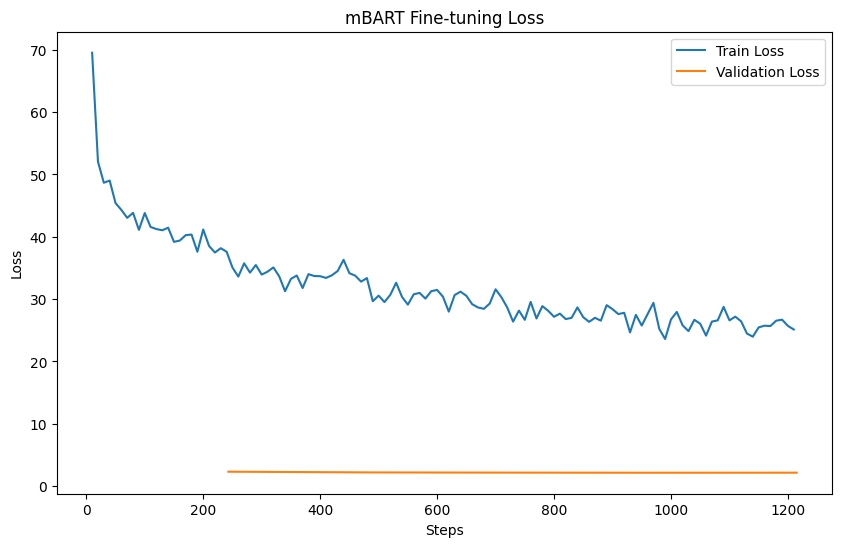

In [ ]:
train_loss = []
eval_loss = []
steps_train = []
steps_eval = []

for log in history:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps_train.append(log["step"])

    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        steps_eval.append(log["step"])

plt.figure(figsize=(10,6))
plt.plot(steps_train, train_loss, label="Train Loss")
plt.plot(steps_eval, eval_loss, label="Validation Loss")
plt.legend()
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("mBART Fine-tuning Loss")
plt.savefig(f"{SAVE_DIR}/loss_curve.png")
plt.show()

In [ ]:
from tqdm import tqdm

In [ ]:
model.eval()

predictions = []
references = []
articles = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    article = row["article"]
    reference = row["summary"]

    inputs = tokenizer(
        article,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=128,
            min_length=20,
            num_beams=4,
            early_stopping=True,
            forced_bos_token_id=tokenizer.lang_code_to_id["ml_IN"]
        )

    pred = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    predictions.append(pred)
    references.append(reference)
    articles.append(article)

print("Predictions done")

100%|██████████| 970/970 [13:29<00:00,  1.20it/s]

Predictions done


In [ ]:
pred_df = pd.DataFrame({
    "article": articles,
    "reference": references,
    "prediction": predictions
})

pred_df.to_csv(
    "/content/drive/MyDrive/mBART_sunday_fine/mbart_test_predictions.csv",
    index=False
)

print("Saved predictions")

Saved predictions


In [ ]:
# ============================================================
# SAMPLE OUTPUTS
# ============================================================

for i in range(10):

    print("="*100)

    print("\nARTICLE:\n")
    print(articles[i])

    print("\nACTUAL SUMMARY:\n")
    print(references[i])

    print("\nPREDICTED SUMMARY:\n")
    print(predictions[i])


ARTICLE:

ദില്ലി: ആള്ക്കൂട്ട കൊലപാതകത്തില് നിയമം ശക്തമാക്കുമെന്ന് വ്യക്തമാക്കി ആഭ്യന്തര മന്ത്രി അമിത് ഷാ.

ACTUAL SUMMARY:

ആള്ക്കൂട്ട കൊല: നിയമം ഭേദഗതി ചെയ്യുമെന്ന് അമിത് ഷാ, കമ്മിറ്റിയുടെ നിര്ദേശം നിര്ണായകം

PREDICTED SUMMARY:

ആള്ക്കൂട്ട കൊലപാതകം: നിയമം ശക്തമാക്കും, അമിത് ഷാ സമ്മതിച്ച് മന്ത്രി

ARTICLE:

പിയിലെ ബി. ജെ. പി നേതാവ് ലാൽജി ടണ്ടന്റെ എഴുപതാം പിറന്നാളാഘോഷത്തിനോടനുബന്ധിച്ച് നടത്തിയ സൗജന്യ സാരി വിതരണത്തിനിടയിലുണ്ടായ തിക്കിലും തിരക്കിലുംപെട്ട് 25 പേർ മരിച്ചു.

ACTUAL SUMMARY:

ബി.ജെ.പി നേതാവിന്റെ പിറന്നാളാഘോഷംഃ സൗജന്യ സാരി വാങ്ങാനെത്തിയ 25 പേർ തിരക്കിൽപ്പെട്ട് മരിച്ചു

PREDICTED SUMMARY:

ബി.ജെ.പി നേതാവ് ലാൽജി ടണ്ടന്റെ പിറന്നാൾ ആഘോഷത്തിനോടനുബന്ധിച്ച് സൗജന്യ സാരി വിതരണത്തിനിട

ARTICLE:

ആലപ്പുഴ: പ്രതി അജാസിനെപ്പറ്റി കൂടുതൽ അന്വേഷണം വേണമെന്നു വള്ളികുന്നത്ത് കൊല്ലപ്പെട്ട സൗമ്യയുടെ ഭർത്താവ് സജീവ്.

ACTUAL SUMMARY:

അന്വേഷണത്തിൽ തൃപ്തിയില്ല; അജാസിനെപ്പറ്റി കൂടുതൽ അന്വേഷണം വേണമെന്നു കൊല്ലപ്പെട്ട സൗമ്യയുടെ ഭർത്താവ് സജീവ്

PREDICTED SUMMARY:

അജാസിന്റെ അന്വേഷണം വേണമെന്ന് വള്ളികുന്നത്

In [ ]:
from rouge_score import rouge_scorer
import sacrebleu
import numpy as np
import pandas as pd
from bert_score import score as bertscore

In [ ]:
rouge = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=False
)

r1 = []
r2 = []
rl = []

for ref, pred in zip(references, predictions):
    s = rouge.score(ref, pred)
    r1.append(s["rouge1"].fmeasure)
    r2.append(s["rouge2"].fmeasure)
    rl.append(s["rougeL"].fmeasure)

bleu = sacrebleu.corpus_bleu(predictions, [references])

P, R, F1 = bertscore(
    predictions,
    references,
    lang="ml"
)

metrics = pd.DataFrame({
    "Metric": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "BLEU",
        "BERTScore-F1"
    ],
    "Score": [
        np.mean(r1),
        np.mean(r2),
        np.mean(rl),
        bleu.score,
        F1.mean().item()
    ]
})

print(metrics)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


         Metric      Score
0       ROUGE-1   0.037835
1       ROUGE-2   0.001718
2       ROUGE-L   0.037835
3          BLEU  14.477410
4  BERTScore-F1   0.756045


In [ ]:
metrics.to_csv(
    "/content/drive/MyDrive/mBART_sunday_fine/mbart_metrics.csv",
    index=False
)

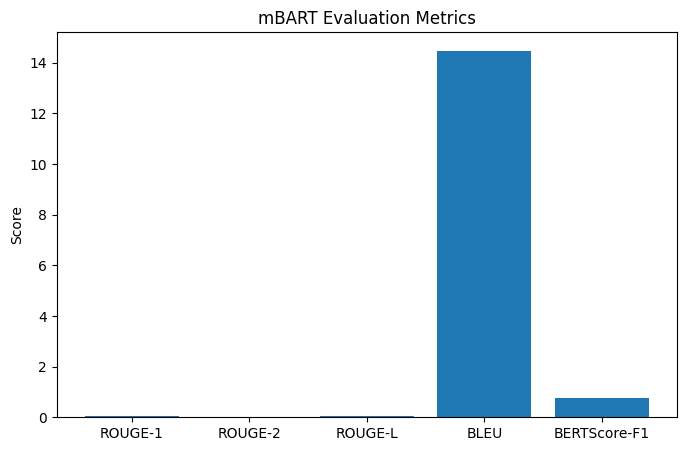

In [ ]:
# ============================================================
# METRICS PLOT
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    metrics["Metric"],
    metrics["Score"]
)

plt.ylabel("Score")
plt.title("mBART Evaluation Metrics")

plt.savefig("/content/drive/MyDrive/mBART_sunday_fine/metrics_plot.png")
plt.show()

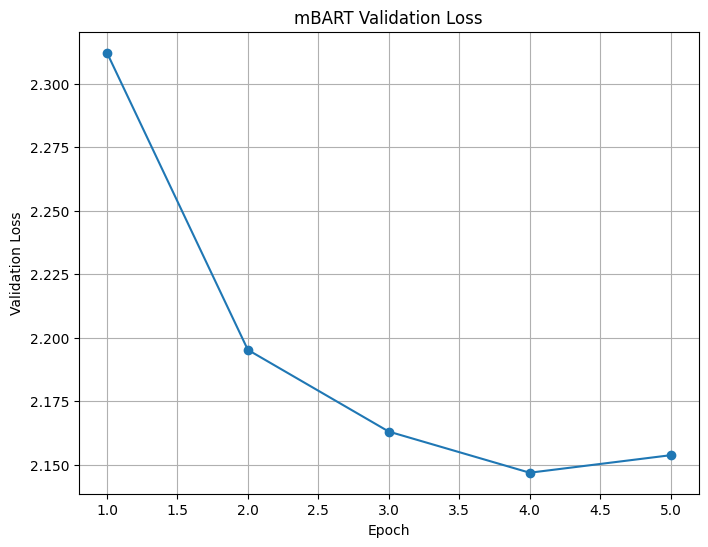

saved


In [ ]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

eval_loss = []
epochs = []

for log in logs:
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        epochs.append(log["epoch"])

plt.figure(figsize=(8,6))
plt.plot(epochs, eval_loss, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("mBART Validation Loss")
plt.grid(True)

plt.savefig("/content/drive/MyDrive/mBART_sunday_fine/mbart_loss_plot.png")
plt.show()

print("saved")

In [ ]:
from google.colab import files

files.download('/content/drive/MyDrive/mbart_sunday_fine/final_model/tokenizer_config.json')
files.download("/content/drive/MyDrive/mBART_sunday_fine/mbart_test_predictions.csv")
files.download("/content/drive/MyDrive/mBART_sunday_fine/mbart_metrics.csv")
files.download("/content/drive/MyDrive/mBART_sunday_fine/mbart_loss_plot.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/drive/MyDrive/mBART_sunday_fine/mbart_metrics.csv")
files.download("/content/drive/MyDrive/mBART_sunday_fine/mbart_loss_plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('/content/drive/MyDrive/mbart_sunday_fine/final_model/tokenizer.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>